In [1]:
# Import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.objects as so
import datetime as dt
from datetime import datetime
import os
import kagglehub

# Change directory to the data location
os.chdir('../../ml_data')

# Read the data
df = pd.read_csv('credit_card_fraud_dataset.csv')
df

/Users/davidal-gurnawi/Documents/data_science/machine_learning/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,TransactionID,TransactionDate,Amount,MerchantID,TransactionType,Location,IsFraud
0,1,2024-04-03 14:15:35.462794,4189.27,688,refund,San Antonio,0
1,2,2024-03-19 13:20:35.462824,2659.71,109,refund,Dallas,0
2,3,2024-01-08 10:08:35.462834,784.00,394,purchase,New York,0
3,4,2024-04-13 23:50:35.462850,3514.40,944,purchase,Philadelphia,0
4,5,2024-07-12 18:51:35.462858,369.07,475,purchase,Phoenix,0
...,...,...,...,...,...,...,...
99995,99996,2024-06-07 00:57:36.027591,1057.29,289,refund,San Antonio,0
99996,99997,2023-10-22 23:12:36.027594,297.25,745,refund,San Antonio,0
99997,99998,2024-05-31 19:27:36.027597,3448.56,690,purchase,San Antonio,0
99998,99999,2024-10-18 09:43:36.027601,3750.79,644,purchase,Philadelphia,0


In [2]:
# Some data formatting
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])

<Axes: xlabel='MerchantID', ylabel='Count'>

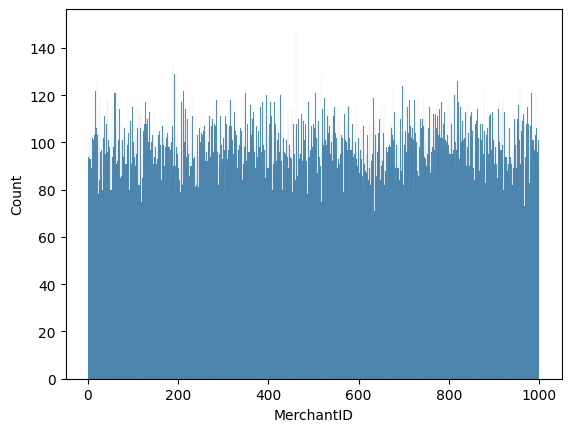

In [3]:
sns.histplot(df, x='MerchantID', discrete=True)

<Axes: xlabel='MerchantID', ylabel='Count'>

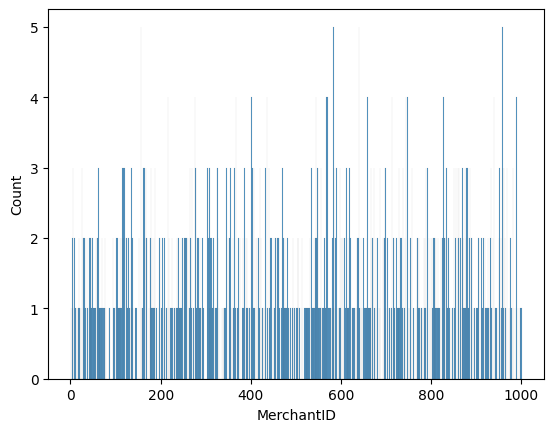

In [4]:
# The overall transactions with all merchants seem to be all over the place
# How does the picture change looking at only fraud cases

sns.histplot(df[df['IsFraud']==1], x='MerchantID', discrete=True)

In [13]:
# Based on the view above, there seem to be some merchants that are more affected by fraud than others.
# Here we could classify a merchant as high risk, depending on the overall cases of fraud
# reported.

fraud = df[df['IsFraud']==1].groupby(by='MerchantID').count().reset_index()
fraud = fraud[['MerchantID', 'IsFraud']]
fraud

,MerchantID,IsFraud
0,1,1
1,3,1
2,4,2
3,5,1
4,6,3
...,...,...
623,992,1
624,997,1
625,998,1
626,999,1
